In [1]:
from sf_workingdir_lilly.dmlab.custom_esn_analysis import get_hidden_states_iso_feat
import torch
import numpy as np
import matplotlib.pyplot as plt


In [10]:
# define parameters
time_steps = 70
#[0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.92, 0.95, 0.97, 0.99]
spectral_radius = [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0] #[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 2, 3, 4, 5, 6, 7, 8]
Hippo_n_feature = 16
Hippo_R = 8
Hippo_L = 64
trial=7
fixed_whh=True
fixed_wih=False

Could not compute length of orthogonal vectors for sr 1.6 and input neuron 14: linalg.svd: The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated singular values (error code: 1).


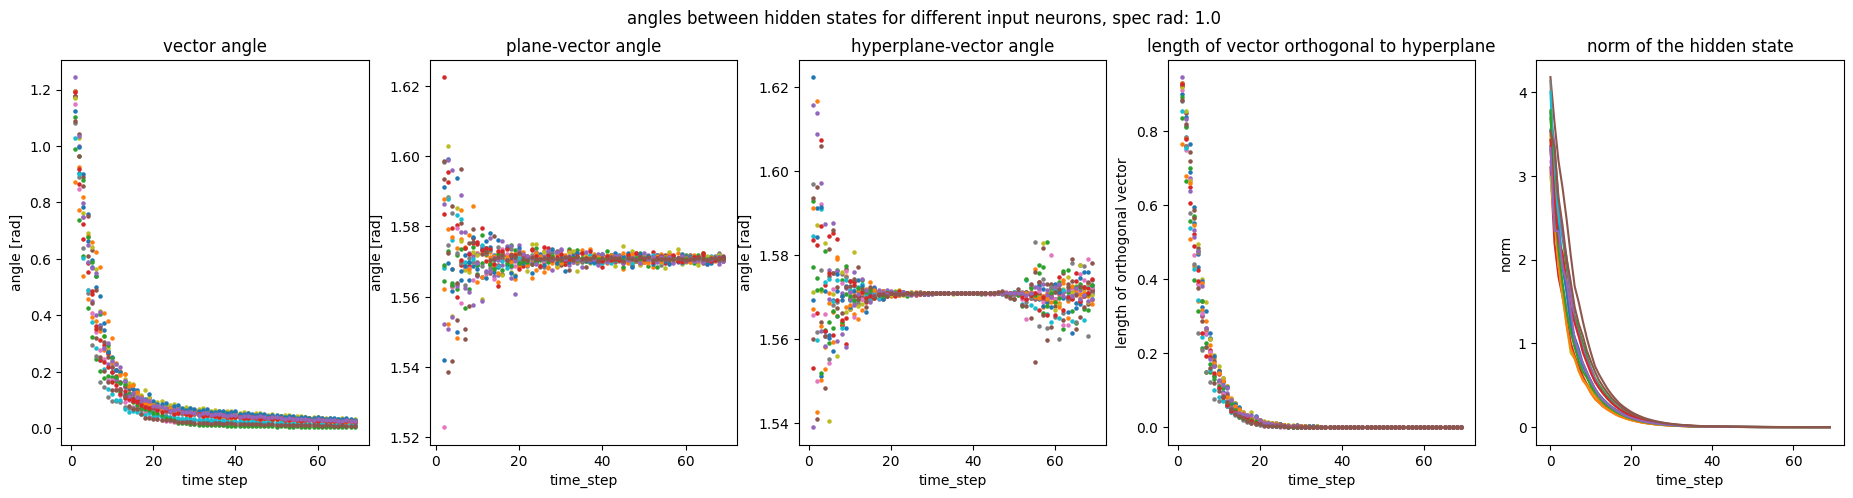

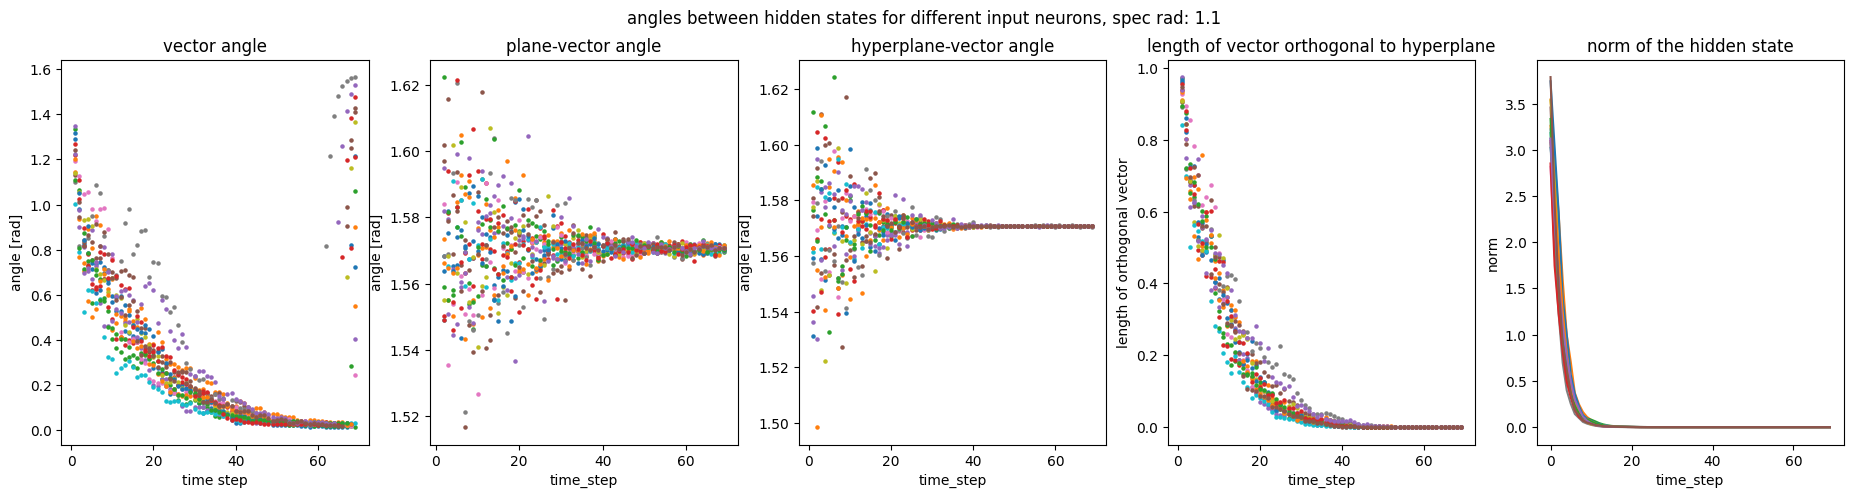

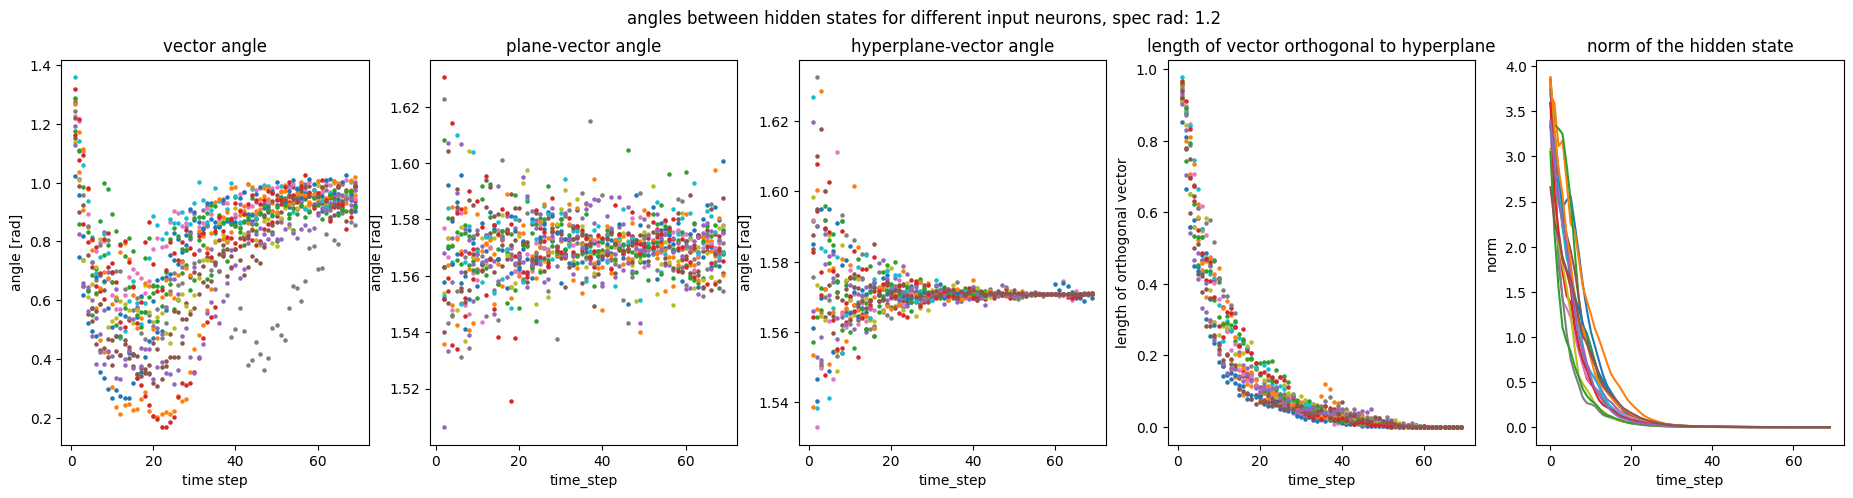

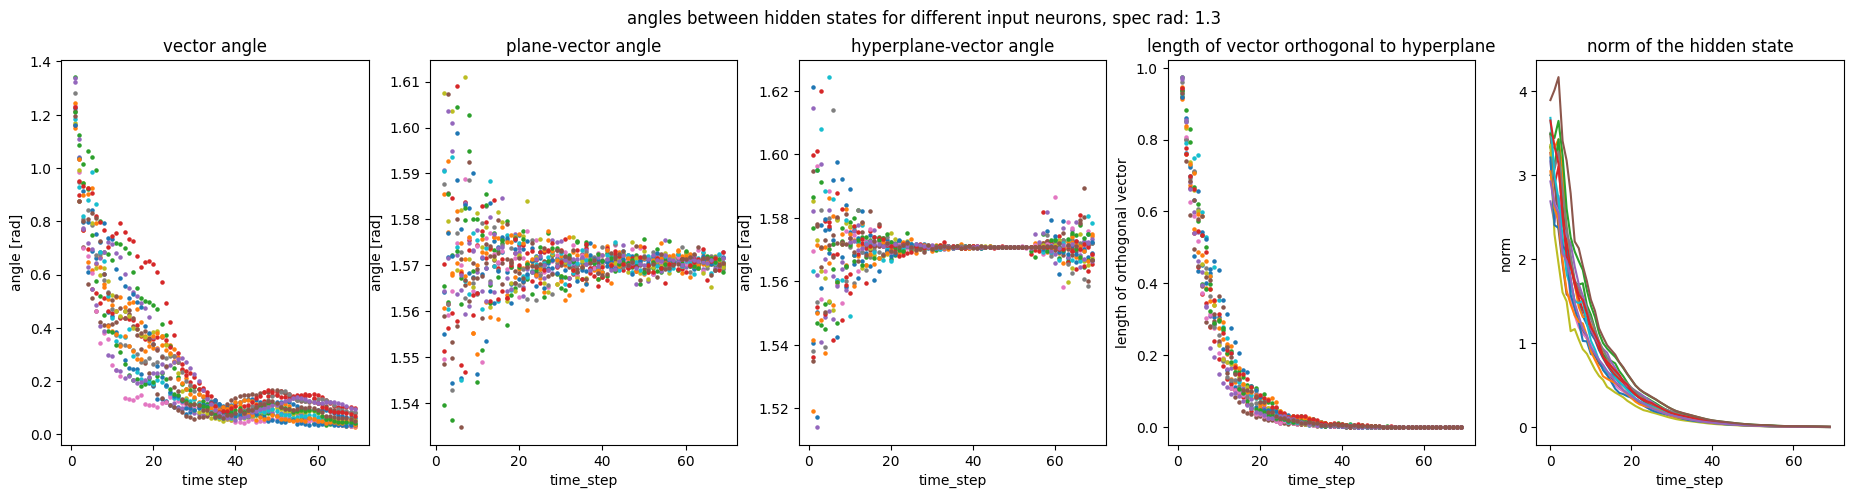

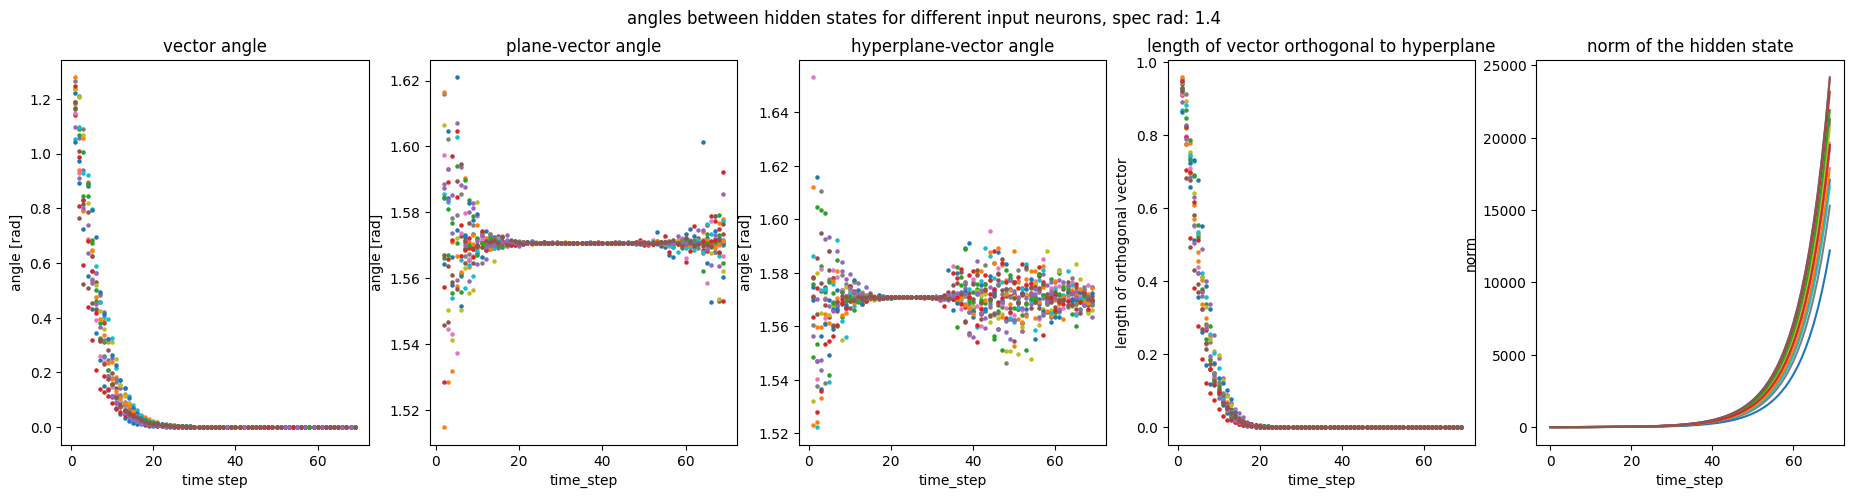

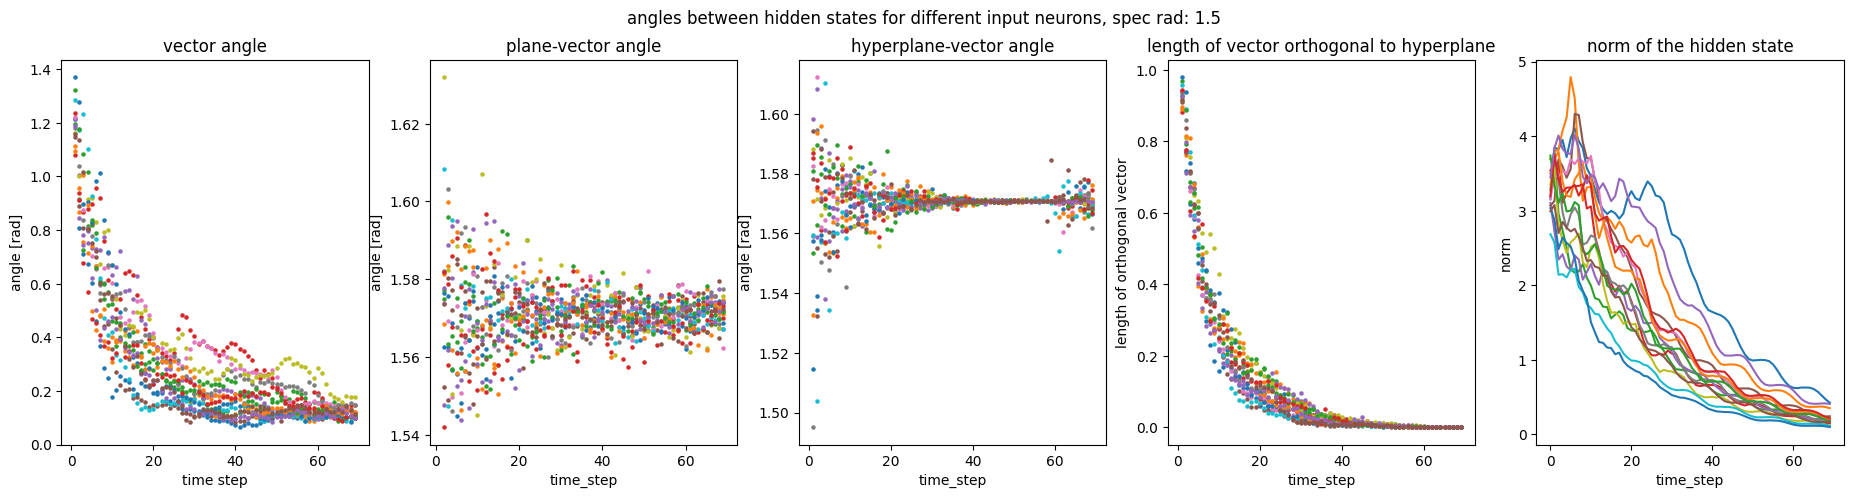

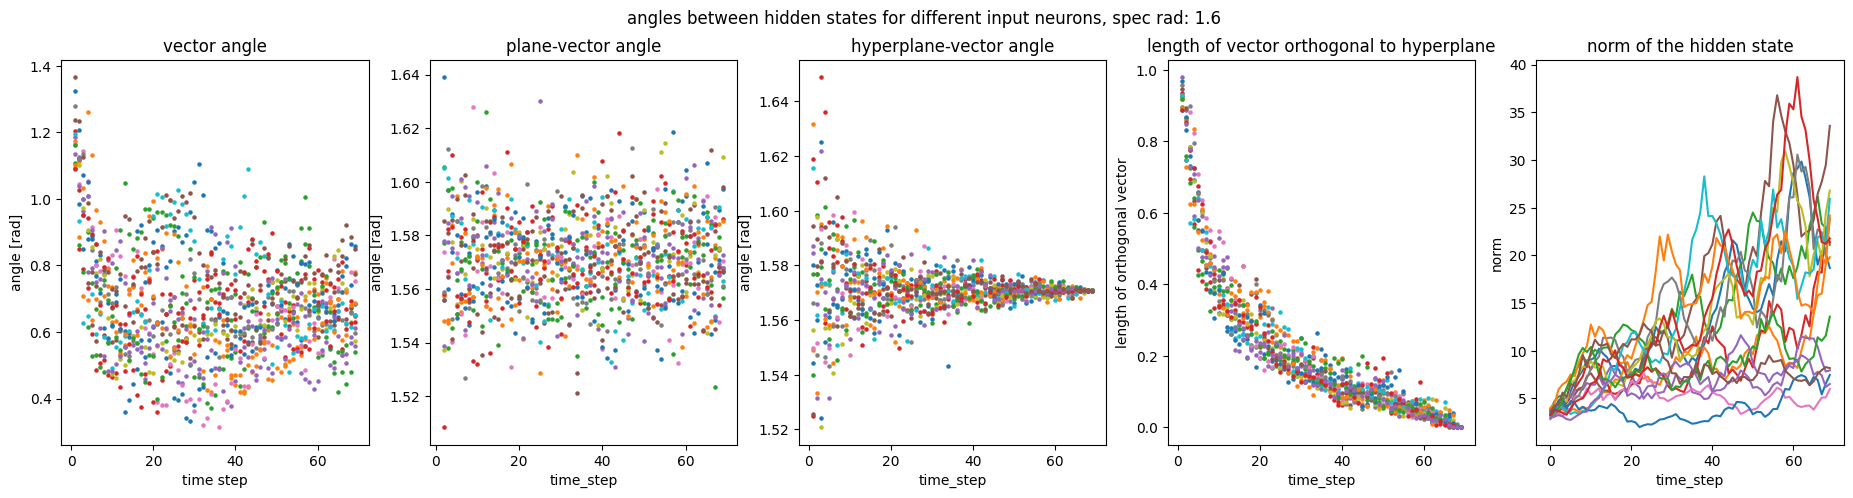

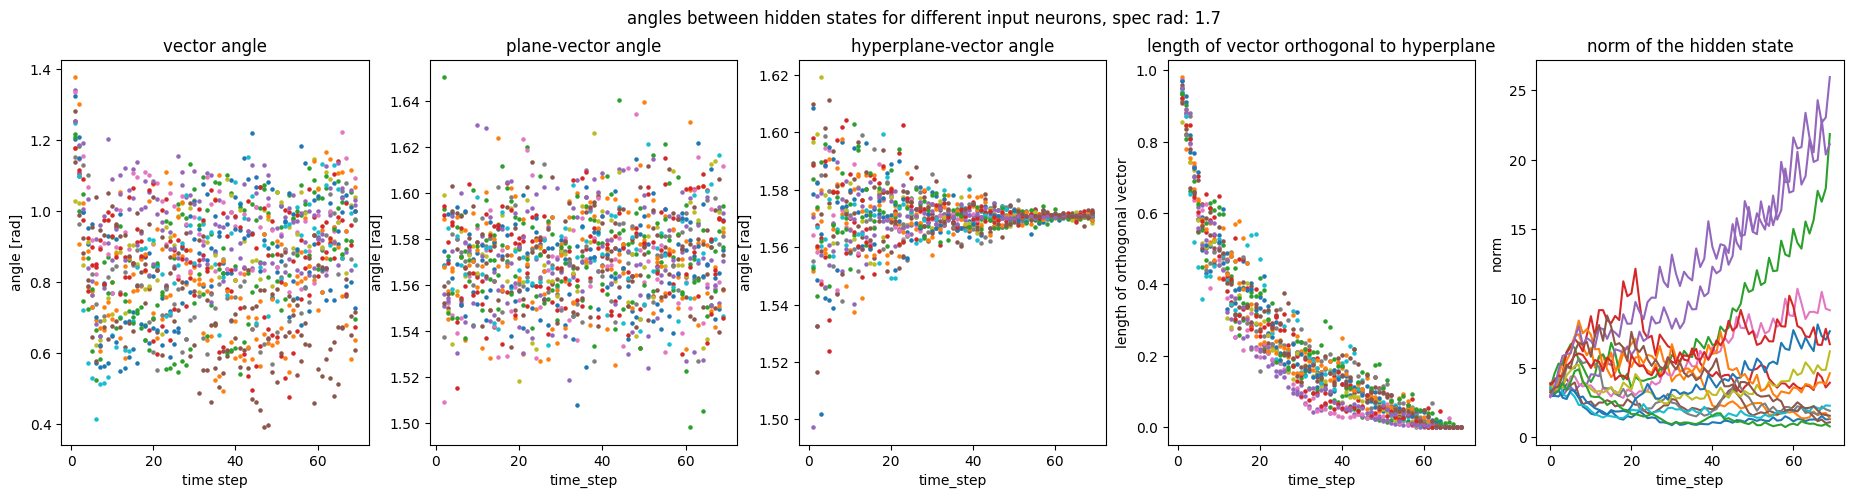

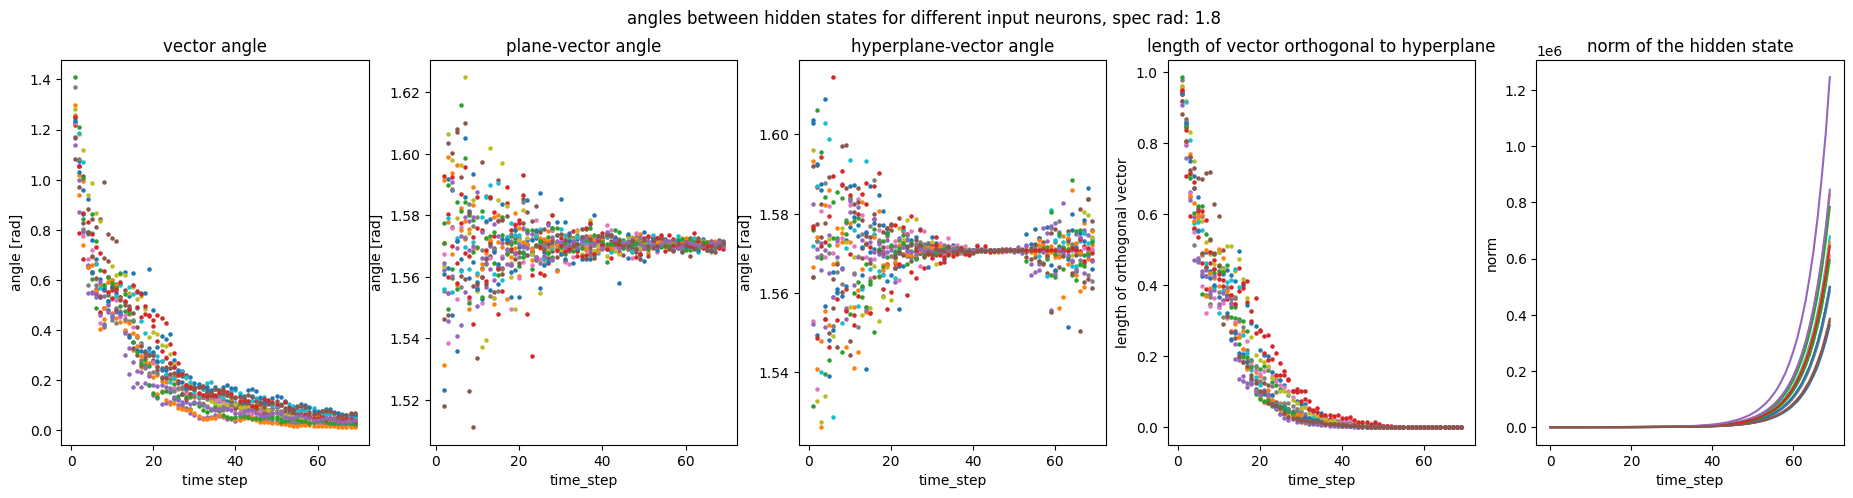

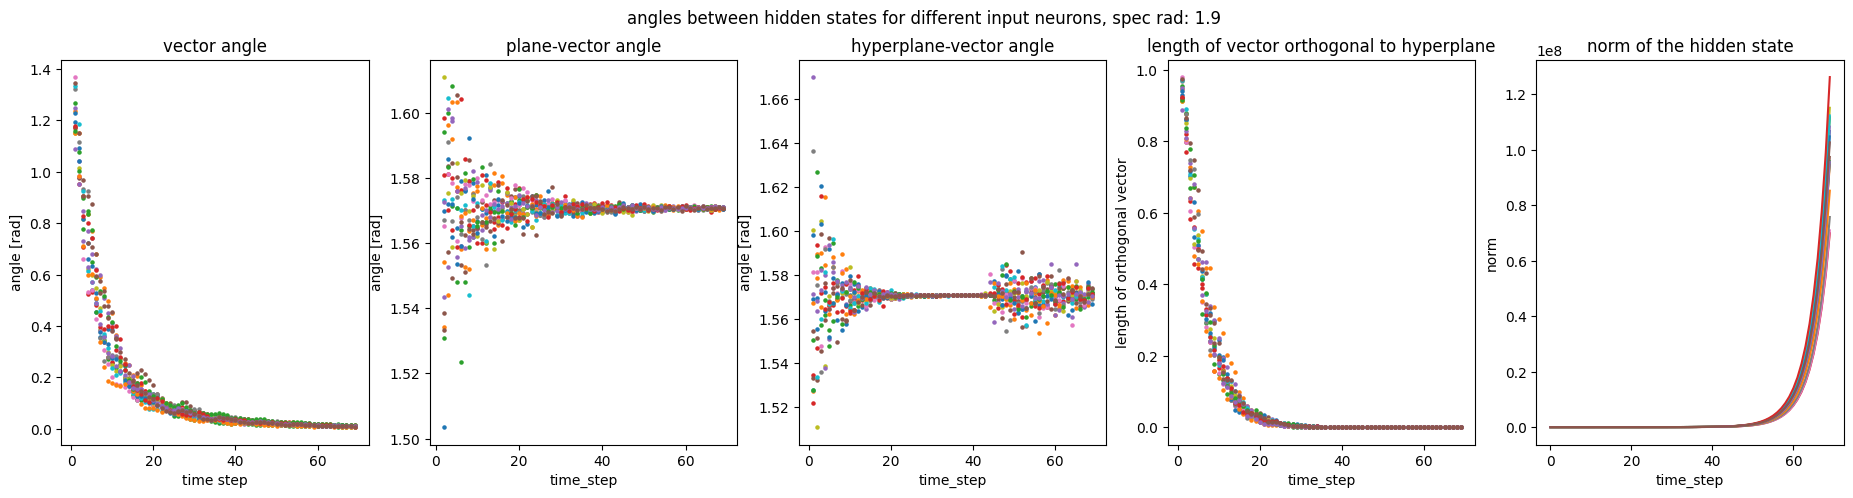

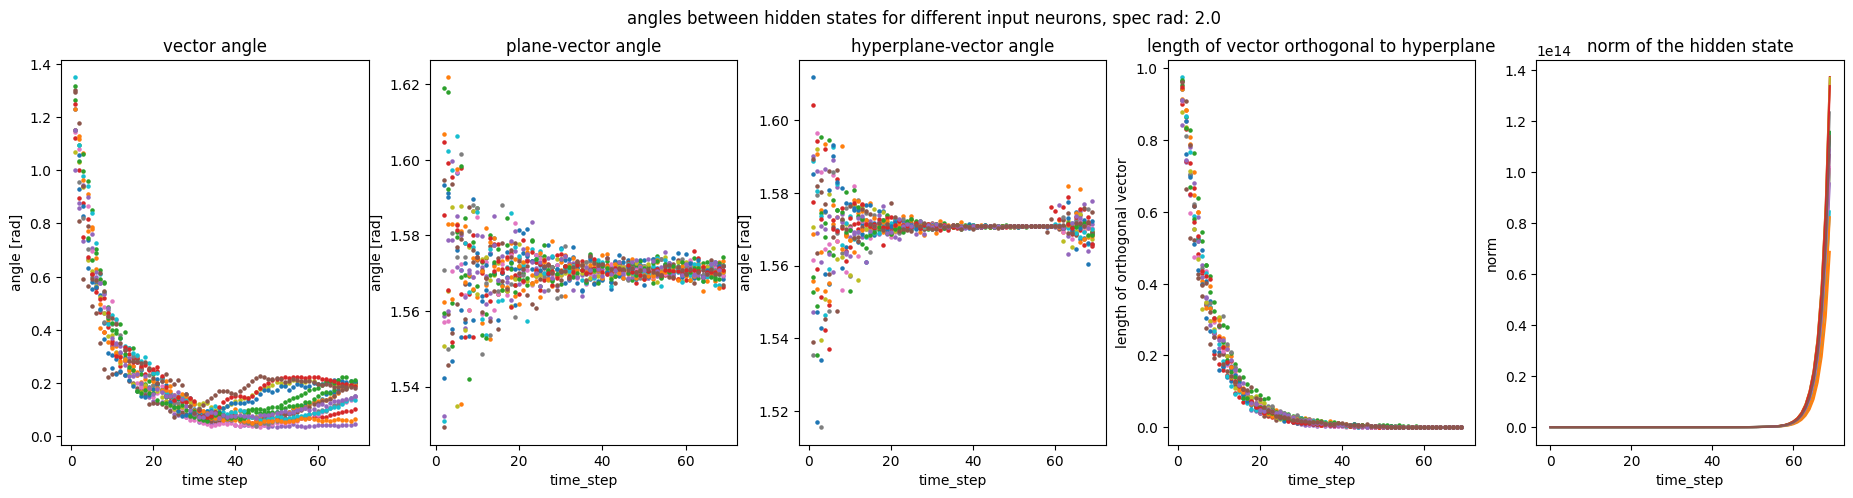

In [14]:
from sf_workingdir_lilly.dmlab.custom_esn_analysis import compute_angle_between_hidden_states, compute_angle_hypperplane_hidden_state, compute_angle_plane_hidden_state, len_new_orth_vec


neuron_norms_for_srs = np.zeros((len(spectral_radius), Hippo_n_feature,time_steps))
x_vals = np.arange(1,70)
x_vals_plane = np.arange(2,70)

for sr_i, sr in enumerate(spectral_radius):
    # create a (input_index, time_steps) matrix for each spectral radius - values in the matrix are the norms at this input index at that tiem - and create a plot where the norms are plotted against the time
    #neuron_norms = np.zeros((Hippo_n_feature,time_steps))
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1,5, figsize=(23,5))
    for i in range(Hippo_n_feature):
        hs = get_hidden_states_iso_feat(time_steps, sr, Hippo_n_feature, Hippo_R, Hippo_L, trial, fixed_whh, fixed_wih, input_idx=i)  # size: (time_steps, hidden_size)
        angles = compute_angle_between_hidden_states(hs, time_steps)
        angles_plane = compute_angle_plane_hidden_state(hs, time_steps)
        angles_hyperplane = compute_angle_hypperplane_hidden_state(hs, time_steps)
        try:
            len_orth_vectos = len_new_orth_vec(hs, time_steps)
            ax4.scatter(x_vals, len_orth_vectos, label=f'{i}', s=5)
        except Exception as e:
            print(f'Could not compute length of orthogonal vectors for sr {sr} and input neuron {i}: {e}')
            pass

        norms = hs.norm(dim=1)
        
        #neuron_norms[i,:] = norms
        neuron_norms_for_srs[sr_i,i,:] = norms
        
        ax1.scatter(x_vals, angles, label=f'{i}', s=5)
        ax2.scatter(x_vals_plane, angles_plane, label=f'{i}', s=5)
        ax3.scatter(x_vals, angles_hyperplane, label=f'{i}', s=5)
        ax5.plot(norms, label=f'{i}')
    
        fig.suptitle(f'angles between hidden states for different input neurons, spec rad: {sr}')
        ax1.set_title('vector angle')
        ax2.set_title('plane-vector angle')
        ax3.set_title('hyperplane-vector angle')
        ax4.set_title('length of vector orthogonal to hyperplane')
        ax5.set_title('norm of the hidden state')

        ax1.set_xlabel('time step')
        ax2.set_xlabel('time_step')
        ax3.set_xlabel('time_step')
        ax4.set_xlabel('time_step')
        ax5.set_xlabel('time_step')

        ax1.set_ylabel('angle [rad]')
        ax2.set_ylabel('angle [rad]')
        ax3.set_ylabel('angle [rad]')
        ax4.set_ylabel('length of orthogonal vector')
        ax5.set_ylabel('norm')

Could not compute length of orthogonal vectors for sr 1.6 and input neuron 14: linalg.svd: The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated singular values (error code: 1).


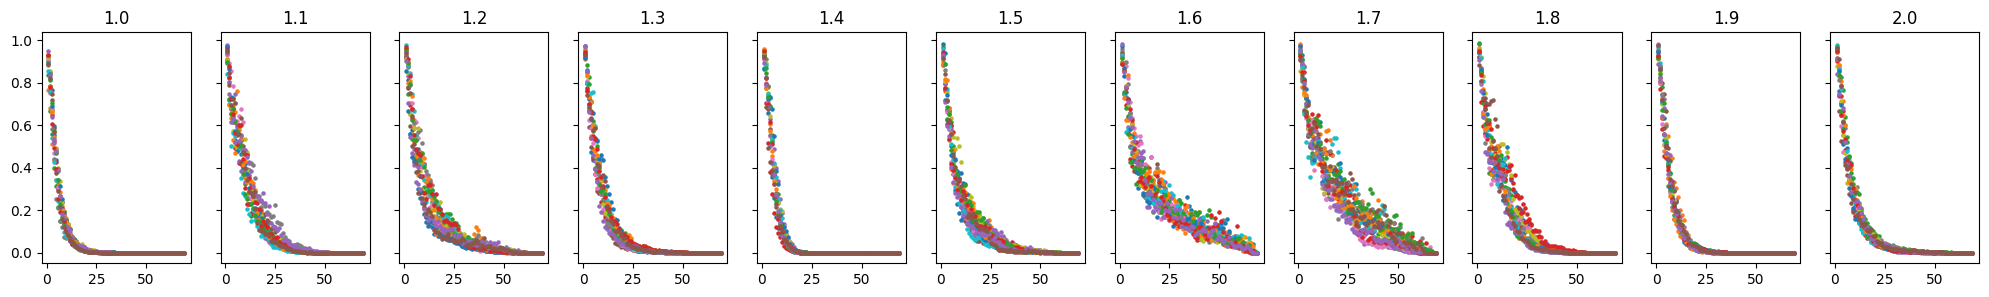

In [24]:
fig, ax = plt.subplots(1,len(spectral_radius), figsize=(25,3), sharey=True, sharex=True)
#fig.supxlabel('time_step')
#fig.supylabel('length of orthogonal vector')
for sr_i, sr in enumerate(spectral_radius):
    for i in range(Hippo_n_feature):
        hs = get_hidden_states_iso_feat(time_steps, sr, Hippo_n_feature, Hippo_R, Hippo_L, trial, fixed_whh, fixed_wih, input_idx=i)  # size: (time_steps, hidden_size)
        try:
            len_orth_vectos = len_new_orth_vec(hs, time_steps)
            ax[sr_i].scatter(x_vals, len_orth_vectos, label=f'{i}', s=5)
        except Exception as e:
            print(f'Could not compute length of orthogonal vectors for sr {sr} and input neuron {i}: {e}')
            pass
        ax[sr_i].set_title(f'{sr}')
        
            

In [ ]:
threshold = 0.05

threshold_was_reached = np.zeros((len(spectral_radius), Hippo_n_feature))

for sr_i, sr in enumerate(spectral_radius):
    for i in range(Hippo_n_feature):
        current_norms = neuron_norms_for_srs[sr_i,i,:]
        threshold_idx = np.where(current_norms <= threshold)
        if not threshold_idx[0].any():
            break
        threshold_was_reached[sr_i,i] = threshold_idx[0][0]

print(threshold_was_reached)
print(spectral_radius)
print(threshold_was_reached.mean(axis=1))

[[ 8.  7.  7.  8.  8.  8.  9.  8.  8.  8.  8.  9.  7.  8.  8.  7.]
 [25. 26. 28. 27. 26. 23. 28. 24. 26. 24. 24. 27. 21. 24. 26. 25.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [41. 41. 34. 41. 57. 40. 44. 60. 46. 37. 41. 51. 59. 52. 45. 37.]
 [45. 56. 52. 50. 44. 48. 53. 53. 44. 56. 54. 51. 56. 57. 42. 53.]
 [47. 33. 37. 33. 36. 28. 44. 36. 31. 30. 31. 39. 43. 40. 45. 26.]
 [30. 34. 38. 30. 39. 36. 36. 34. 29. 36. 32. 37. 29. 30. 32. 34.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]]
[1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
[ 7.875  25.25    0.     45.375  50.875  36.1875 33.5     0.      0.
  0.      0.    ]
